In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [5]:
order_level_df = pd.read_csv('outputs/order_level_df.csv')
delivered_df = pd.read_csv('outputs/delivered_orders_df.csv')

print(order_level_df.shape)
print(delivered_df.shape)

(99441, 33)
(96478, 33)


In [6]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_cols:
    if col in order_level_df.columns:
        order_level_df[col] = pd.to_datetime(order_level_df[col], errors='coerce')
    if col in delivered_df.columns:
        delivered_df[col] = pd.to_datetime(delivered_df[col], errors='coerce')

order_level_df.head()

,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_creation_date,review_answer_timestamp,customer_city,customer_state,order_item_count,product_count,seller_count,category_count,total_price,total_freight,review_score,total_payment,payment_installments,purchase_year,purchase_month,purchase_day,order_value,approval_delay_days,delivery_days,carrier_to_customer_days,delivery_delay_days,is_late_delivery,review_bucket,order_value_bucket
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017-09-21,2017-09-22 10:57:03,campos dos goytacazes,RJ,1,1,1,1,58.90,13.29,5.0,72.19,2.0,2017,2017-09,Wednesday,72.19,0.032326,7.614421,1.214954,-8.011250,0,Good,Mid-Low
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017-05-13,2017-05-15 11:34:13,santa fe do sul,SP,1,1,1,1,239.90,19.93,4.0,259.83,3.0,2017,2017-04,Wednesday,259.83,0.008414,16.216181,8.062083,-2.330278,0,Good,High Value
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018-01-23,2018-01-23 16:06:31,para de minas,MG,1,1,1,1,199.00,17.87,5.0,216.87,5.0,2018,2018-01,Sunday,216.87,0.010405,7.948437,6.029491,-13.444954,0,Good,High Value
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018-08-15,2018-08-15 16:39:01,atibaia,SP,1,1,1,1,12.99,12.79,4.0,25.78,2.0,2018,2018-08,Wednesday,25.78,0.006748,6.147269,4.003229,-5.435660,0,Good,Low Value
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,2017-03-02,2017-03-03 10:54:59,varzea paulista,SP,1,1,1,1,199.90,18.14,5.0,218.04,3.0,2017,2017-02,Saturday,218.04,0.008588,25.114352,13.289144,-15.303808,0,Good,High Value


## Revenue and Order Performance
Analyze how orders, revenue, and average order value change over time.

In [7]:
monthly_kpi = order_level_df.groupby('purchase_month', as_index=False).agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('order_value', 'sum'),
    avg_order_value=('order_value', 'mean')
).sort_values('purchase_month')

monthly_kpi.head()

,purchase_month,total_orders,total_revenue,avg_order_value
0,2016-09,4,354.75,88.687500
1,2016-10,324,58730.85,181.268056
2,2016-12,1,19.62,19.620000
3,2017-01,800,148030.11,185.037638
4,2017-02,1780,303648.31,170.588938


### Monthly Order Trend
Track how total marketplace orders change over time.

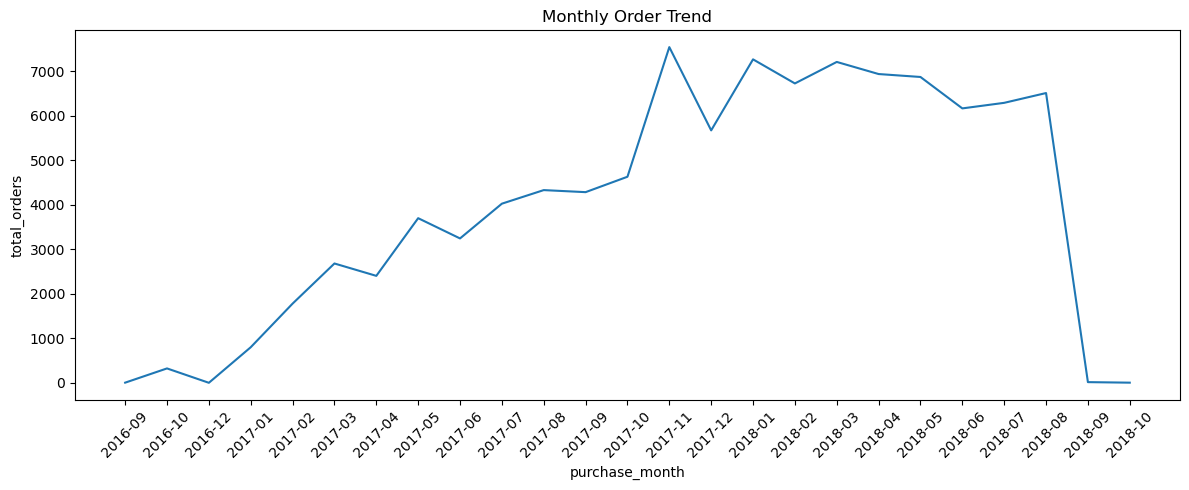

In [8]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_kpi, x='purchase_month', y='total_orders')
plt.title('Monthly Order Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Order volume generally grows over time, showing marketplace expansion with some monthly fluctuations.

### Monthly Revenue Trend
Track how total marketplace revenue changes over time.

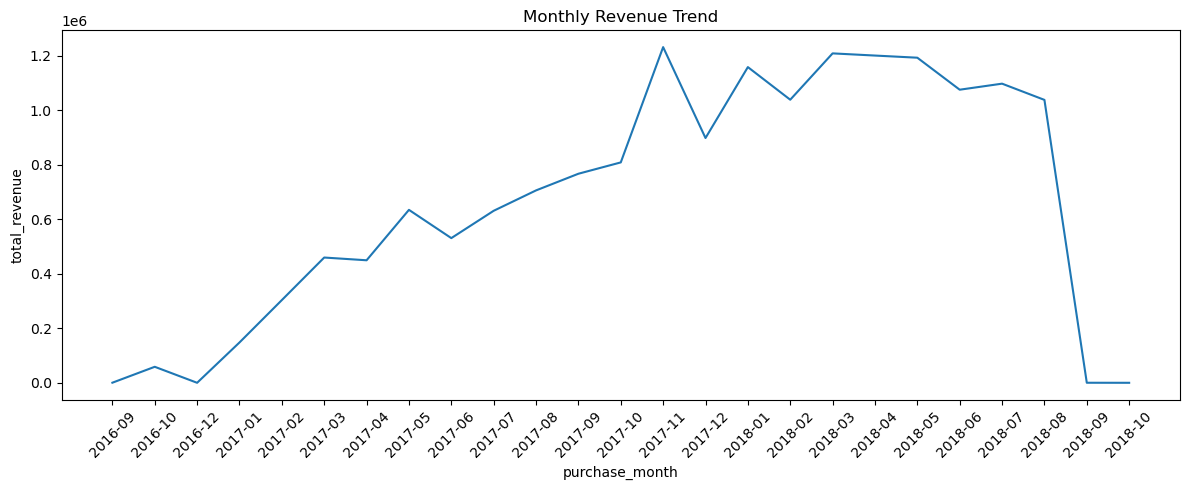

In [9]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_kpi, x='purchase_month', y='total_revenue')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Revenue shows a clear growth pattern over time, broadly following order volume and indicating overall marketplace expansion.

### Average Order Value Trend
Check whether changes in revenue are driven only by order volume or also by order value.

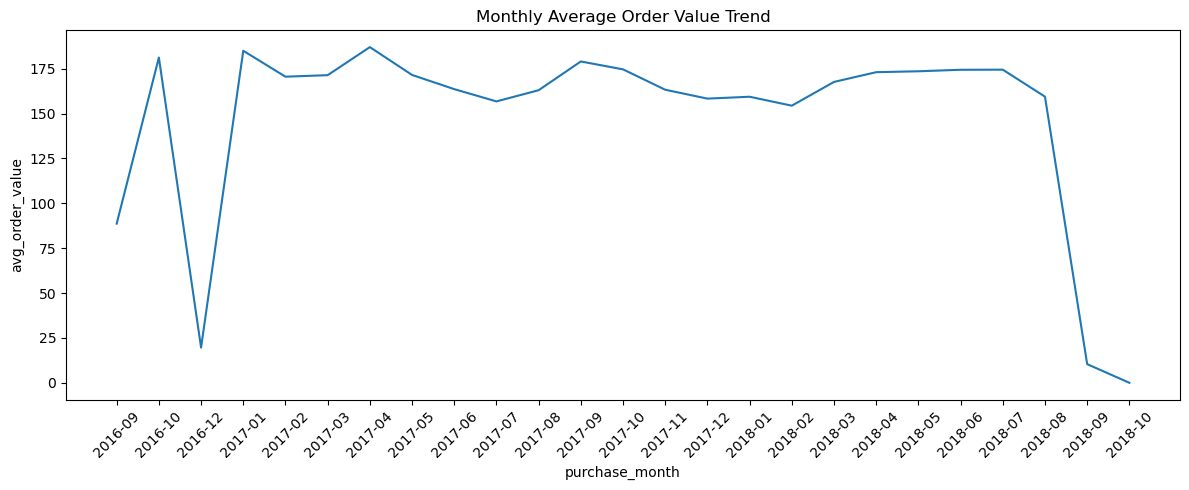

In [10]:
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_kpi, x='purchase_month', y='avg_order_value')
plt.title('Monthly Average Order Value Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Average order value is more stable than total orders and revenue, suggesting that marketplace growth is driven mainly by order volume rather than major shifts in basket value.

**Section Summary:** Orders and revenue increased strongly over time, while average order value stayed relatively stable. This suggests marketplace growth was driven more by rising demand than by larger order sizes.

## Fulfillment and Delivery Performance
Evaluate delivery speed, late deliveries, and operational efficiency.

### Delivery Performance Overview
Summarize core delivery metrics for delivered orders.

In [11]:
delivery_kpis = delivered_df[['delivery_days', 'carrier_to_customer_days', 'delivery_delay_days']].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

delivery_kpis

,delivery_days,carrier_to_customer_days,delivery_delay_days
mean,12.56,9.33,-11.18
median,10.22,7.10,-11.95
min,0.53,0.00,-146.02
max,209.63,205.19,188.98


**Insight:** Delivered orders are typically completed before the estimated delivery date, although delivery times still vary significantly across orders.

### Late Delivery Rate
Measure how often delivered orders arrive after the estimated delivery date.

In [12]:
late_delivery_rate = delivered_df['is_late_delivery'].mean() * 100
print(f"Late delivery rate: {late_delivery_rate:.2f}%")

Late delivery rate: 8.11%


**Insight:** Most delivered orders arrive on time or early, but the share of late deliveries still represents an important operational risk.

**Insight:** Most delivered orders arrive on time or early, but the share of late deliveries still represents an important operational risk.

### Review Score by Delivery Outcome
Compare customer satisfaction for late and on-time deliveries.

In [13]:
review_by_delivery = delivered_df.groupby('is_late_delivery', as_index=False).agg(
    avg_review_score=('review_score', 'mean'),
    total_orders=('order_id', 'nunique')
).round(2)

review_by_delivery['delivery_status'] = review_by_delivery['is_late_delivery'].map({
    0: 'On-Time / Early',
    1: 'Late'
})

review_by_delivery[['delivery_status', 'avg_review_score', 'total_orders']]

,delivery_status,avg_review_score,total_orders
0,On-Time / Early,4.30,88652
1,Late,2.57,7826


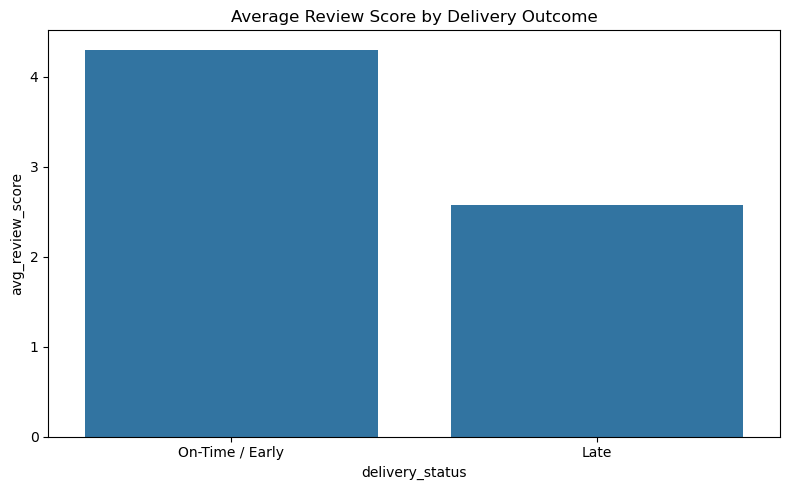

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(data=review_by_delivery, x='delivery_status', y='avg_review_score')
plt.title('Average Review Score by Delivery Outcome')
plt.tight_layout()
plt.show()

**Insight:** Late deliveries receive lower average review scores, showing a clear link between operational delay and customer satisfaction.

## Regional Risk Analysis
Compare delivery and satisfaction performance across customer states.

In [15]:
state_summary = delivered_df.groupby('customer_state', as_index=False).agg(
    total_orders=('order_id', 'nunique'),
    avg_delivery_days=('delivery_days', 'mean'),
    late_delivery_rate=('is_late_delivery', 'mean'),
    avg_review_score=('review_score', 'mean'),
    total_revenue=('order_value', 'sum')
).round(2)

state_summary['late_delivery_rate'] = state_summary['late_delivery_rate'] * 100

state_summary.sort_values('late_delivery_rate', ascending=False).head(10)

,customer_state,total_orders,avg_delivery_days,late_delivery_rate,avg_review_score,total_revenue
1,AL,397,24.54,24.0,3.86,97724.79
9,MA,717,21.57,20.0,3.83,151814.71
16,PI,476,19.46,16.0,3.99,111665.76
24,SE,335,21.52,15.0,3.91,72694.76
5,CE,1279,21.27,15.0,3.94,281430.06
4,BA,3256,19.34,14.0,3.93,627081.41
26,TO,274,17.66,13.0,4.15,68355.46
18,RJ,12350,15.31,13.0,3.97,2167521.77
11,MS,701,15.62,12.0,4.16,139757.80
21,RR,41,29.39,12.0,3.90,9039.52


**Insight:** State-level performance varies meaningfully, showing that delivery experience and customer satisfaction are not equally distributed across regions.

### States with the Highest Late Delivery Rate
Highlight the regions with the greatest delivery risk.

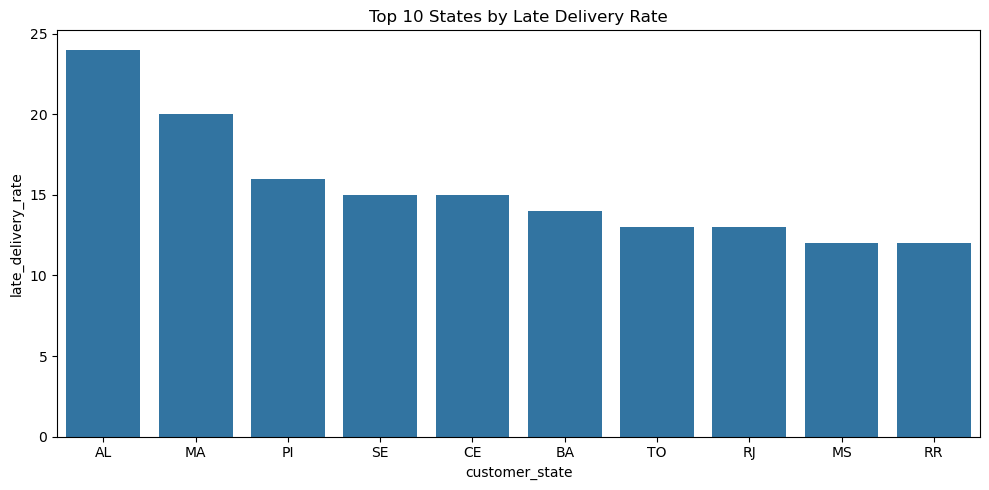

In [16]:
top_late_states = state_summary.sort_values('late_delivery_rate', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_late_states, x='customer_state', y='late_delivery_rate')
plt.title('Top 10 States by Late Delivery Rate')
plt.tight_layout()
plt.show()

**Insight:** Some states face much higher late-delivery risk than others, pointing to regional logistics challenges that may require targeted operational improvement.

### States with the Lowest Average Review Scores
Identify regions where customer satisfaction is weakest.

In [17]:
low_review_states = state_summary.sort_values('avg_review_score', ascending=True).head(10)

low_review_states[['customer_state', 'avg_review_score', 'late_delivery_rate', 'avg_delivery_days', 'total_orders']]

,customer_state,avg_review_score,late_delivery_rate,avg_delivery_days,total_orders
9,MA,3.83,20.0,21.57,717
1,AL,3.86,24.0,24.54,397
21,RR,3.90,12.0,29.39,41
13,PA,3.91,12.0,23.77,946
24,SE,3.91,15.0,21.52,335
4,BA,3.93,14.0,19.34,3256
5,CE,3.94,15.0,21.27,1279
18,RJ,3.97,13.0,15.31,12350
16,PI,3.99,16.0,19.46,476
7,ES,4.08,12.0,15.79,1995


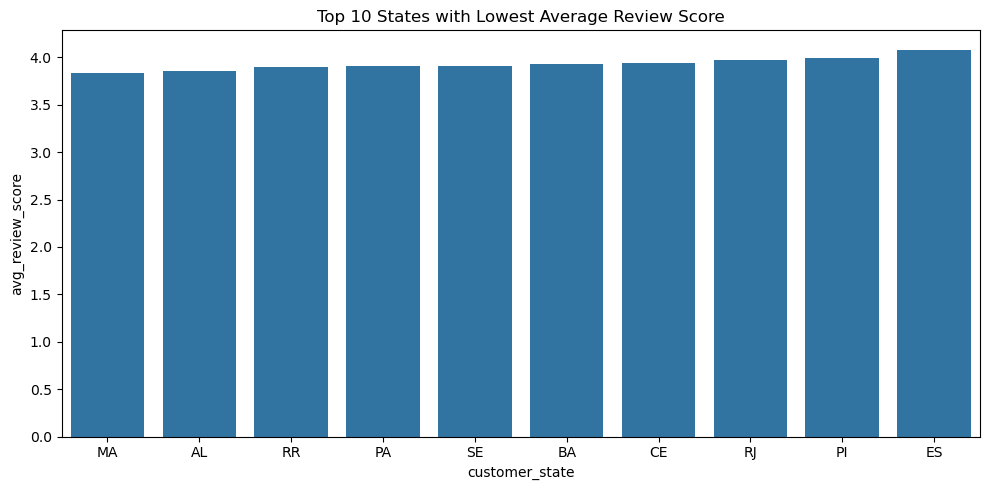

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(data=low_review_states, x='customer_state', y='avg_review_score')
plt.title('Top 10 States with Lowest Average Review Score')
plt.tight_layout()
plt.show()

**Insight:** States with lower review scores often also show weaker delivery performance, reinforcing the link between operations and customer satisfaction.

## Commercial Performance vs Customer Experience
Examine whether higher-value orders are linked to better or worse customer experience.

### Review Score by Order Value Segment
Compare customer satisfaction across order value buckets.

In [20]:
value_review_summary = delivered_df.groupby('order_value_bucket', as_index=False).agg(
    total_orders=('order_id', 'nunique'),
    avg_order_value=('order_value', 'mean'),
    avg_review_score=('review_score', 'mean'),
    late_delivery_rate=('is_late_delivery', 'mean')
).round(2)

value_review_summary['late_delivery_rate'] = value_review_summary['late_delivery_rate'] * 100

value_review_summary

,order_value_bucket,total_orders,avg_order_value,avg_review_score,late_delivery_rate
0,High Value,24197,402.51,4.05,9.0
1,Low Value,23598,43.17,4.24,7.0
2,Mid-High,24340,140.30,4.16,8.0
3,Mid-Low,24343,82.79,4.18,8.0


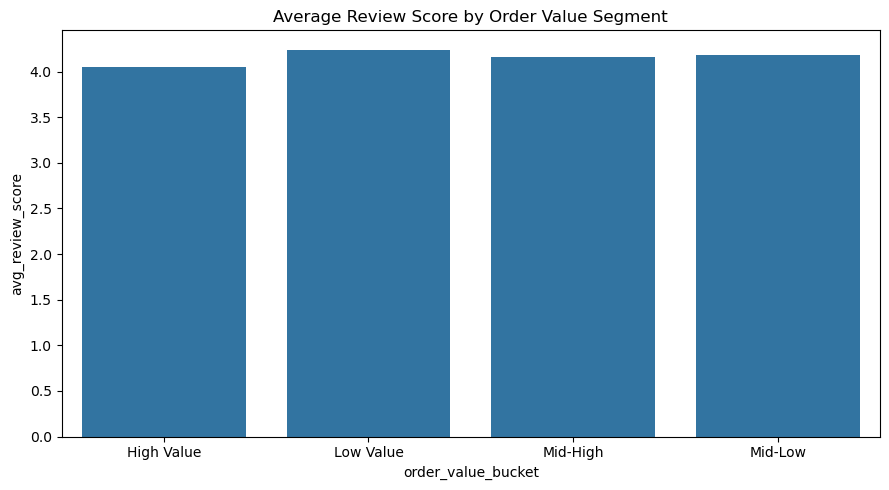

In [21]:
plt.figure(figsize=(9,5))
sns.barplot(data=value_review_summary, x='order_value_bucket', y='avg_review_score')
plt.title('Average Review Score by Order Value Segment')
plt.tight_layout()
plt.show()

**Insight:** Higher-value orders do not automatically receive better ratings, showing that commercial value alone does not guarantee a stronger customer experience.

### Late Delivery Rate by Order Value Segment
Check whether higher-value orders carry greater delivery risk.

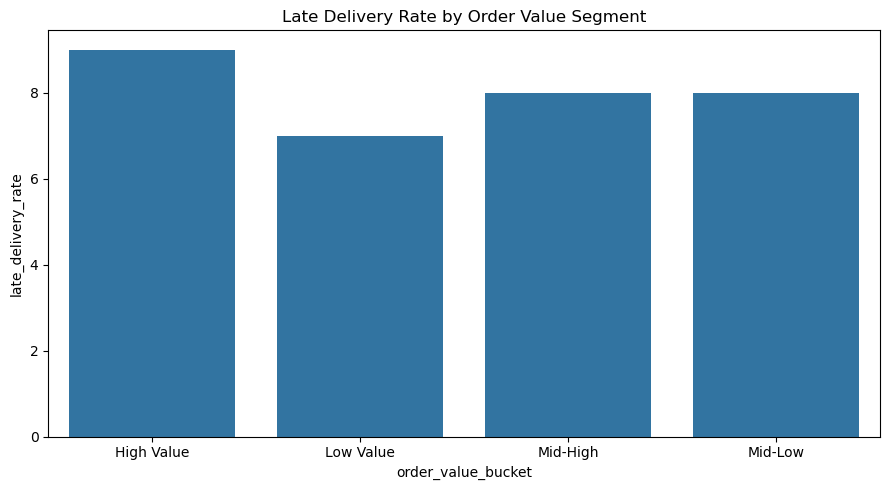

In [23]:
plt.figure(figsize=(9,5))
sns.barplot(data=value_review_summary, x='order_value_bucket', y='late_delivery_rate')
plt.title('Late Delivery Rate by Order Value Segment')
plt.tight_layout()
plt.show()

**Insight:** Delivery risk can still appear in higher-value segments, which means strong revenue performance may come with operational pressure.

## Seller Performance Trade-Off Analysis
Identify sellers with strong sales performance but weaker service quality.

In [26]:
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [27]:
seller_order_df = order_items[['order_id', 'seller_id']].drop_duplicates()

seller_metrics = seller_order_df.merge(
    delivered_df[['order_id', 'order_value', 'review_score', 'is_late_delivery']],
    on='order_id',
    how='inner'
)

seller_summary = seller_metrics.groupby('seller_id', as_index=False).agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('order_value', 'sum'),
    avg_review_score=('review_score', 'mean'),
    late_delivery_rate=('is_late_delivery', 'mean')
).round(2)

seller_summary['late_delivery_rate'] = seller_summary['late_delivery_rate'] * 100

top_sellers = seller_summary.sort_values('total_revenue', ascending=False).head(10)

top_sellers

,seller_id,total_orders,total_revenue,avg_review_score,late_delivery_rate
858,4a3ca9315b744ce9f8e9374361493884,1772,262438.46,3.86,11.0
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,259720.36,4.15,12.0
1480,7c67e1448b00f6e969d365cea6b010ab,973,254262.70,3.50,10.0
982,53243585a1d6dc2643021fd1853d8905,348,253822.62,4.19,4.0
2903,fa1c13f2614d7b5c4749cbc52fecda94,578,212953.27,4.37,10.0
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,202831.09,4.18,8.0
188,1025f0e2d44d7041d6cf58b6550e0bfa,910,182467.31,4.02,10.0
1504,7e93a43ef30c4f03f38b393420bc753a,319,179588.26,4.36,6.0
1450,7a67c85e85bb2ce8582c35f2203ad736,1145,174898.65,4.28,6.0
1758,955fee9216a65b617aa5c0531780ce60,1261,160667.93,4.20,8.0


In [28]:
seller_order_df = order_items[['order_id', 'seller_id']].drop_duplicates()

seller_metrics = seller_order_df.merge(
    delivered_df[['order_id', 'order_value', 'review_score', 'is_late_delivery']],
    on='order_id',
    how='inner'
)

seller_summary = seller_metrics.groupby('seller_id', as_index=False).agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('order_value', 'sum'),
    avg_review_score=('review_score', 'mean'),
    late_delivery_rate=('is_late_delivery', 'mean')
).round(2)

seller_summary['late_delivery_rate'] = seller_summary['late_delivery_rate'] * 100

top_sellers = seller_summary.sort_values('total_revenue', ascending=False).head(10)

top_sellers

,seller_id,total_orders,total_revenue,avg_review_score,late_delivery_rate
858,4a3ca9315b744ce9f8e9374361493884,1772,262438.46,3.86,11.0
834,4869f7a5dfa277a7dca6462dcf3b52b2,1124,259720.36,4.15,12.0
1480,7c67e1448b00f6e969d365cea6b010ab,973,254262.70,3.50,10.0
982,53243585a1d6dc2643021fd1853d8905,348,253822.62,4.19,4.0
2903,fa1c13f2614d7b5c4749cbc52fecda94,578,212953.27,4.37,10.0
2543,da8622b14eb17ae2831f4ac5b9dab84a,1311,202831.09,4.18,8.0
188,1025f0e2d44d7041d6cf58b6550e0bfa,910,182467.31,4.02,10.0
1504,7e93a43ef30c4f03f38b393420bc753a,319,179588.26,4.36,6.0
1450,7a67c85e85bb2ce8582c35f2203ad736,1145,174898.65,4.28,6.0
1758,955fee9216a65b617aa5c0531780ce60,1261,160667.93,4.20,8.0


### Top 10 Sellers by Revenue
Identify the highest-revenue sellers in the marketplace.

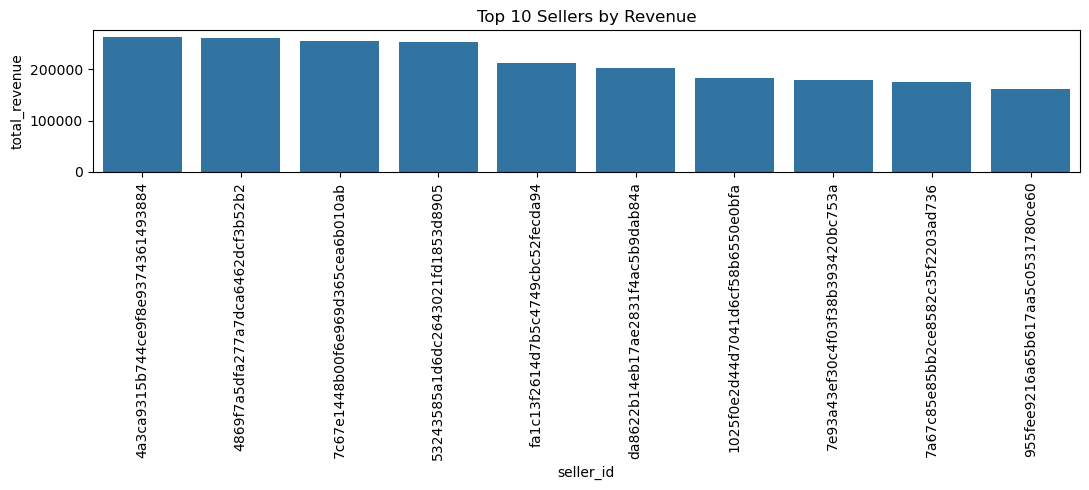

In [29]:
plt.figure(figsize=(11,5))
sns.barplot(data=top_sellers, x='seller_id', y='total_revenue')
plt.title('Top 10 Sellers by Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Insight:** A small group of sellers contributes a disproportionately large share of revenue, making seller performance an important marketplace dependency.

### Review Score for Top Revenue Sellers
Compare customer satisfaction across the highest-revenue sellers.

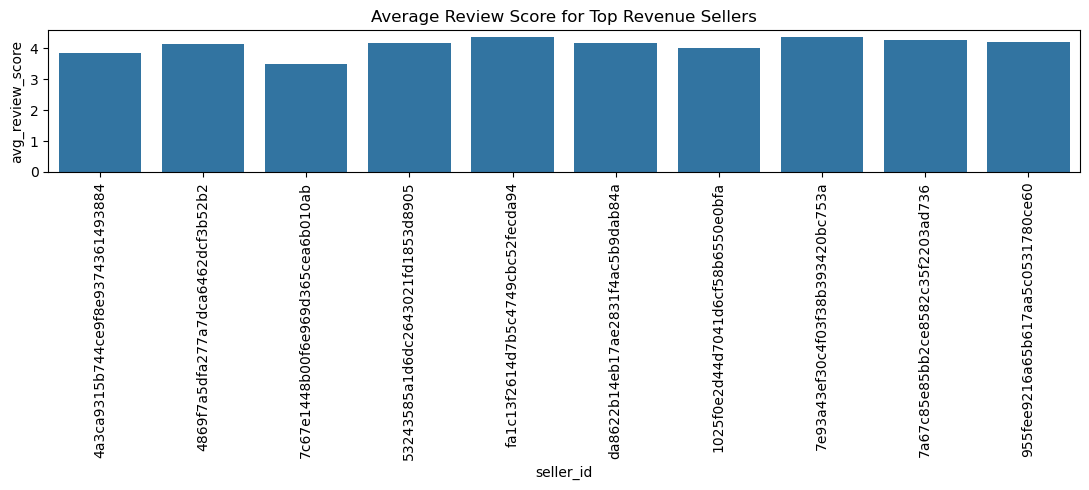

In [30]:
plt.figure(figsize=(11,5))
sns.barplot(data=top_sellers, x='seller_id', y='avg_review_score')
plt.title('Average Review Score for Top Revenue Sellers')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:** Not all top-revenue sellers deliver the same customer experience, showing that revenue strength and service quality do not always move together.

## Key Insights Summary

- Orders and revenue increased strongly over time, indicating overall marketplace growth.
- Average order value remained relatively stable, suggesting growth was driven mainly by higher order volume.
- Most orders were delivered on time or early, but late deliveries had a strong negative effect on review scores.
- Delivery performance and customer satisfaction varied across states, showing regional operational risk.
- Higher-value orders did not always produce better customer experience, highlighting a trade-off between revenue and service quality.
- Top sellers drove major revenue contribution, but some showed weaker experience metrics, which may create platform risk.